In [1]:
pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00


In [2]:
from google.colab import files

uploaded = files.upload()

Saving my_photo.jpg to my_photo.jpg


In [3]:

#cell 3 — CSC 110 Lab: Object Detection with YOLO

# Step A: Import the YOLO class from the ultralytics library
from ultralytics import YOLO

# Step B: Load the YOLO model
# "yolov8n.pt" is the smallest (and fastest) version of YOLO
# The "n" stands for "nano" - great for beginners!
# The first time you run this, it will download the model automatically.
model = YOLO("yolov8n.pt")

# Step C: Run object detection on your image
# ⚠️ Replace "your_photo.jpg" with the exact filename you uploaded in Cell 2
results = model("my_photo.jpg")

# Step D: Print the results in a readable way
print("\n========== DETECTION RESULTS ==========")

# Loop through each result (there is usually just one for a single image)
for result in results:

    # Get the list of detected objects
    boxes = result.boxes

    # Check if anything was detected
    if len(boxes) == 0:
        print("No objects were detected in the image.")
    else:
        print(f"Number of objects detected: {len(boxes)}\n")

        # Loop through each detected object
        for i, box in enumerate(boxes):

            # Get the class ID (a number that represents the object type)
            class_id = int(box.cls)

            # Get the name of the detected object (e.g., "person", "car")
            object_name = result.names[class_id]

            # Get the confidence score (how sure the model is, from 0 to 1)
            confidence = float(box.conf)

            # Convert confidence to a percentage
            confidence_percent = confidence * 100

            # Print the result for this object
            print(f"Object {i+1}: {object_name}")
            print(f"   Confidence: {confidence_percent:.1f}%")
            print()

print("========================================")
print("Lab complete! Great job!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/my_photo.jpg: 640x384 1 person, 1 kite, 1 tv, 329.7ms
Speed: 14.5ms preprocess, 329.7ms inference, 48.0ms postprocess per image at shape (1, 3, 640, 384)

========== DETECTION RESULTS ==========
Number of objects detected: 3

Object 1: person
   Confidence: 90.4%

Object 2: tv
   Confidence: 66.9%

Object 3: kite
   Confidence: 34.5%

Lab complete! Great job!


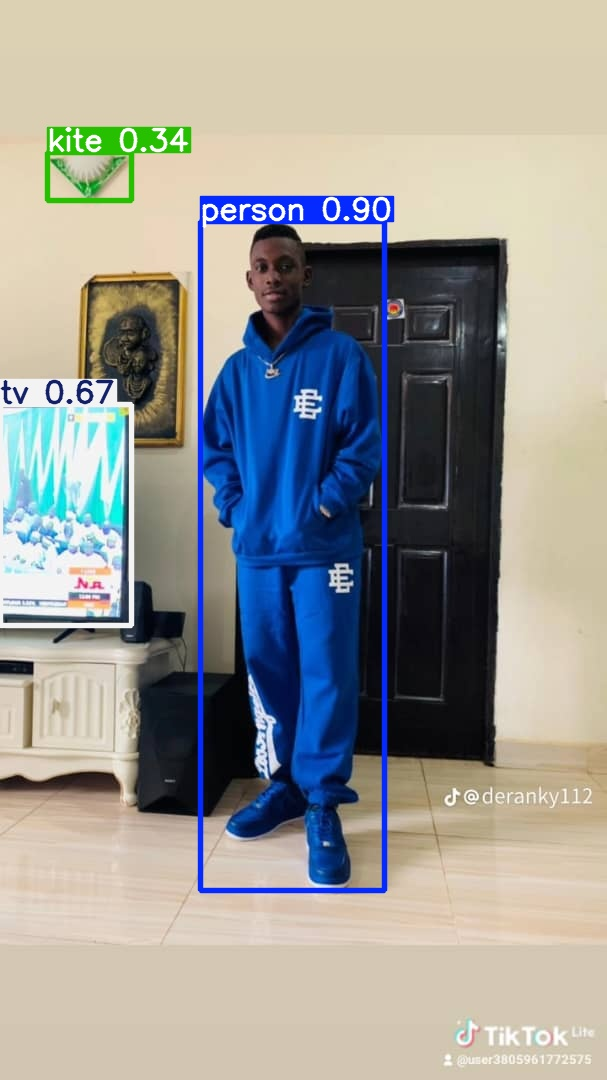

In [4]:
# Cell 4 (Bonus): Save and display the annotated image inside Colab
from IPython.display import Image as IPImage

# Save the result image with boxes drawn on it
results[0].save(filename="output_image.jpg")

# Display it directly inside the notebook
IPImage("output_image.jpg")